In [21]:

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings("ignore")
import os
CHARTS = "./charts"
os.makedirs(CHARTS, exist_ok=True) 
COLORS = {
    "Extreme Fear" : "#d62728",
    "Fear"         : "#ff7f0e",
    "Neutral"      : "#7f7f7f",
    "Greed"        : "#2ca02c",
    "Extreme Greed": "#1f77b4",
}
SENT_ORDER  = ["Extreme Fear", "Fear", "Neutral", "Greed", "Extreme Greed"]
colors_bin  = {"Fear": "#ff7f0e", "Neutral": "#7f7f7f", "Greed": "#2ca02c"}

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)

def save(name):
    plt.savefig(f"{CHARTS}/{name}.png", dpi=150, bbox_inches="tight")
    plt.close()

## Part A — Data Preparation

### A1. Load & Document Datasets

In [25]:
fg_raw = pd.read_csv(r"C:\Users\Admin\OneDrive\Desktop\primetrade.ai assignment\fear_greed_index.csv")
ht_raw = pd.read_csv(r"C:\Users\Admin\OneDrive\Desktop\primetrade.ai assignment\historical_data.csv")
print("=== Fear/Greed Index ===")
print(f"  Rows: {fg_raw.shape[0]:,}  |  Columns: {fg_raw.shape[1]}")
print(f"  Missing values: {fg_raw.isnull().sum().sum()}")
print(f"  Date range: {fg_raw['date'].min()} → {fg_raw['date'].max()}")
print(f"  Classifications: {fg_raw['classification'].value_counts().to_dict()}")

print("\n=== Historical Trade Data ===")
print(f"  Rows: {ht_raw.shape[0]:,}  |  Columns: {ht_raw.shape[1]}")
print(f"  Missing values: {ht_raw.isnull().sum().sum()}")
print(f"  Columns: {ht_raw.columns.tolist()}")
print("\nData types:")
display(ht_raw.dtypes.to_frame("dtype"))


=== Fear/Greed Index ===
  Rows: 2,644  |  Columns: 4
  Missing values: 0
  Date range: 2018-02-01 → 2025-05-02
  Classifications: {'Fear': 781, 'Greed': 633, 'Extreme Fear': 508, 'Neutral': 396, 'Extreme Greed': 326}

=== Historical Trade Data ===
  Rows: 211,224  |  Columns: 16
  Missing values: 0
  Columns: ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']

Data types:


,dtype
Account,str
Coin,str
Execution Price,float64
Size Tokens,float64
Size USD,float64
Side,str
Timestamp IST,str
Start Position,float64
Direction,str
Closed PnL,float64


### A2. Clean & Align by Date

In [14]:
# ── Fear/Greed ────────────────────────────────
fg = fg_raw.copy()
fg["date"] = pd.to_datetime(fg["date"]).dt.date
fg.drop_duplicates(subset="date", keep="last", inplace=True)
fg["classification"] = pd.Categorical(fg["classification"], categories=SENT_ORDER, ordered=True)
fg["sentiment_bin"] = fg["classification"].apply(
    lambda x: "Fear" if "Fear" in str(x) else ("Greed" if "Greed" in str(x) else "Neutral")
)
# ── Trades ────────────────────────────────────
ht = ht_raw.copy()
ht["dt"]   = pd.to_datetime(ht["Timestamp IST"], format="%d-%m-%Y %H:%M", dayfirst=True)
ht["date"] = ht["dt"].dt.date

before = len(ht)
ht.drop_duplicates(subset=["Transaction Hash","Trade ID"], keep="first", inplace=True)
print(f"Duplicates removed: {before - len(ht):,} rows  →  {len(ht):,} remain")
print(f"Unique traders    : {ht['Account'].nunique()}")
print(f"Unique coins      : {ht['Coin'].nunique()}")
print(f"Date range        : {ht['date'].min()} → {ht['date'].max()}")


Duplicates removed: 10,105 rows  →  201,119 remain
Unique traders    : 32
Unique coins      : 231
Date range        : 2023-05-01 → 2025-05-01


In [15]:
# Direction flags
ht["is_long"]  = ht["Direction"].isin(["Open Long","Close Short","Buy","Long > Short"]).astype(int)
ht["is_short"] = ht["Direction"].isin(["Open Short","Close Long","Sell","Short > Long"]).astype(int)
ht["is_close"] = ht["Direction"].str.startswith("Close").fillna(False)

# ── Merge ─────────────────────────────────────
merged = ht.merge(fg[["date","value","classification","sentiment_bin"]], on="date", how="inner")
print(f"\nMerged (inner join): {len(merged):,} rows")


Merged (inner join): 201,113 rows


### A3. Compute Key Metrics

In [16]:
def compute_daily_trader_metrics(df):
    g = df.groupby(["Account","date","classification","sentiment_bin"])
    agg = g.agg(
        total_pnl       = ("Closed PnL","sum"),
        n_trades        = ("Trade ID","count"),
        avg_size_usd    = ("Size USD","mean"),
        total_size_usd  = ("Size USD","sum"),
        n_wins          = ("Closed PnL", lambda x: (x > 0).sum()),
        n_losses        = ("Closed PnL", lambda x: (x < 0).sum()),
        gross_profit    = ("Closed PnL", lambda x: x[x > 0].sum()),
        gross_loss      = ("Closed PnL", lambda x: x[x < 0].sum()),
        long_trades     = ("is_long","sum"),
        short_trades    = ("is_short","sum"),
        total_fee       = ("Fee","sum"),
        max_single_pnl  = ("Closed PnL","max"),
        min_single_pnl  = ("Closed PnL","min"),
    ).reset_index()
    agg["win_rate"]         = agg["n_wins"] / (agg["n_wins"] + agg["n_losses"]).clip(lower=1)
    agg["ls_ratio"]         = (agg["long_trades"] + 1) / (agg["short_trades"] + 1)
    agg["net_pnl_after_fee"]= agg["total_pnl"] - agg["total_fee"]
    return agg

daily = compute_daily_trader_metrics(merged)

# Per-trader lifetime stats
trader_stats = daily.groupby("Account").agg(
    total_pnl       = ("total_pnl","sum"),
    total_trades    = ("n_trades","sum"),
    active_days     = ("date","nunique"),
    avg_daily_pnl   = ("total_pnl","mean"),
    win_rate        = ("win_rate","mean"),
    avg_size_usd    = ("avg_size_usd","mean"),
    pnl_std         = ("total_pnl","std"),
    max_drawdown_day= ("total_pnl","min"),
).reset_index()
trader_stats["trades_per_day"] = trader_stats["total_trades"] / trader_stats["active_days"]
trader_stats["sharpe_proxy"]   = (
    trader_stats["avg_daily_pnl"] / trader_stats["pnl_std"].replace(0, np.nan)
)

print(f"Daily trader-days: {len(daily):,}")
print("\nTrader-level summary:")
display(trader_stats[["total_pnl","total_trades","win_rate","avg_size_usd","trades_per_day"]].describe().round(2))

Daily trader-days: 2,304

Trader-level summary:


,total_pnl,total_trades,win_rate,avg_size_usd,trades_per_day
count,32.00,32.00,32.00,32.00,32.00
mean,305769.96,6284.78,0.58,9388.55,109.30
std,465479.85,7630.06,0.18,9403.85,137.83
min,-151777.30,316.00,0.24,486.09,9.56
25%,44437.46,1342.50,0.46,2675.81,32.22
50%,115176.85,3541.00,0.57,4625.84,62.55
75%,386970.73,8691.50,0.72,12469.22,136.66
max,1974785.62,36600.00,0.87,33881.24,702.11


## Part B — Analysis

### B1. Does performance differ between Fear vs Greed days?


In [17]:
perf_by_sent = daily.groupby("sentiment_bin").agg(
    avg_daily_pnl = ("total_pnl","mean"),
    med_daily_pnl = ("total_pnl","median"),
    avg_win_rate  = ("win_rate","mean"),
    avg_drawdown  = ("min_single_pnl","mean"),
    n_obs         = ("total_pnl","count"),
).reindex(["Fear","Neutral","Greed"]).reset_index()
display(perf_by_sent.round(3))

fear_pnl  = daily[daily["sentiment_bin"]=="Fear"]["total_pnl"]
greed_pnl = daily[daily["sentiment_bin"]=="Greed"]["total_pnl"]
t, p = stats.mannwhitneyu(fear_pnl, greed_pnl, alternative="two-sided")
print(f"\nMann-Whitney U (Fear vs Greed PnL): U={t:.0f},  p={p:.4f}")
print("→ Marginally significant" if p < 0.1 else "→ Not statistically significant at α=0.05")

,sentiment_bin,avg_daily_pnl,med_daily_pnl,avg_win_rate,avg_drawdown,n_obs
0,Fear,5126.392,132.720,0.621,-447.745,773
1,Neutral,3384.431,183.400,0.625,-243.892,369
2,Greed,3935.527,276.222,0.621,-305.900,1162



Mann-Whitney U (Fear vs Greed PnL): U=428886,  p=0.0897
→ Marginally significant


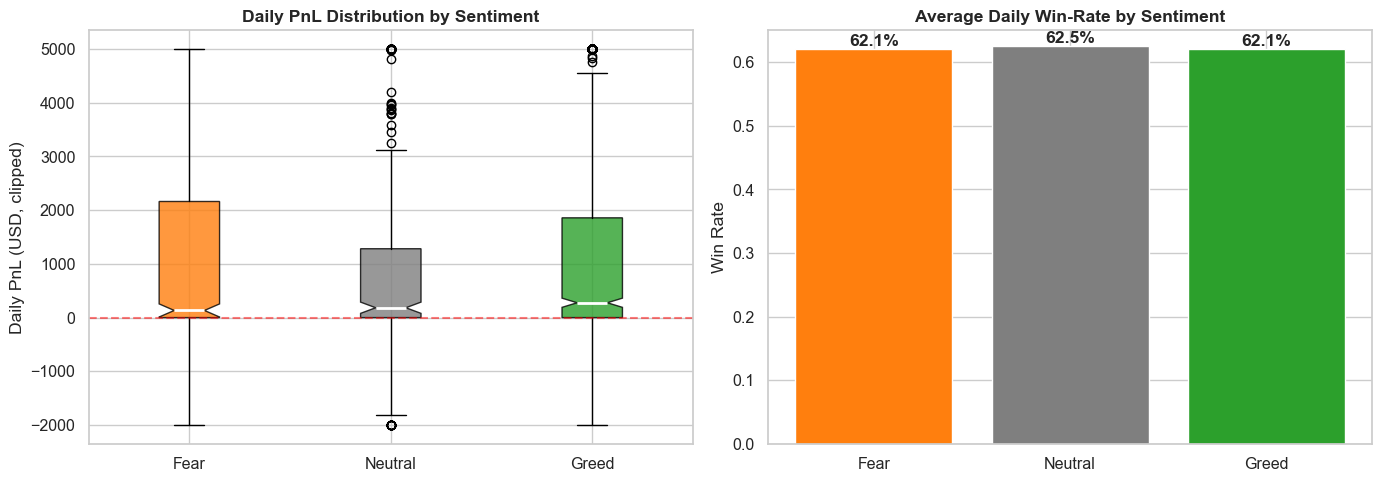

In [27]:
# Chart 1: PnL Distribution + Win Rate
fig, axes = plt.subplots(1, 2, figsize=(14,5))
order = ["Fear","Neutral","Greed"]

bp_data = [daily[daily["sentiment_bin"]==s]["total_pnl"].clip(-2000,5000) for s in order]
bp = axes[0].boxplot(bp_data, labels=order, patch_artist=True, notch=True,
                     medianprops=dict(color="white",linewidth=2))
for patch, s in zip(bp["boxes"], order):
    patch.set_facecolor(colors_bin[s]); patch.set_alpha(0.8)
axes[0].set_title("Daily PnL Distribution by Sentiment", fontweight="bold")
axes[0].set_ylabel("Daily PnL (USD, clipped)")
axes[0].axhline(0, color="red", linestyle="--", alpha=0.5)

win_data = daily.groupby("sentiment_bin")["win_rate"].mean().reindex(order)
bars = axes[1].bar(order, win_data.values, color=[colors_bin[s] for s in order], edgecolor="white")
for bar, val in zip(bars, win_data.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f"{val:.1%}", ha="center", fontweight="bold")
axes[1].set_title("Average Daily Win-Rate by Sentiment", fontweight="bold")
axes[1].set_ylabel("Win Rate"); axes[1].set_ylim(0,0.65)

plt.tight_layout()
plt.show()
save("chart1_pnl_winrate_by_sentiment")



### Chart 1: PnL Distribution & Win Rate by Sentiment

**Key Observations:**

**1. Fear days have the widest PnL spread (highest risk)**
The Fear box plot is the tallest, with the interquartile range
stretching from  ~$0  to ~$2,100. This indicates extreme variation
between traders — a small number of traders made very large profits
while the majority earned close to nothing. The median PnL on Fear
days is just $133, the lowest of all three regimes.

**2. Greed days produce the most consistent profits**
The Greed box sits higher overall with a median PnL of $276 —
more than double Fear's median. The box shape is more compact,
suggesting traders experienced more predictable, reliable returns
during Greed periods rather than a few outliers skewing the result.

**3. Win rate is almost identical across all sentiments (~62%)**
Despite the large difference in PnL distributions, traders win
roughly 6 out of every 10 trades regardless of whether the market
is in Fear or Greed. This tells us sentiment does not affect
*how often* traders win — it affects *how much* they win or lose
when they do.

**Insight:**
Fear days are high risk, high variance — a few traders profit
enormously while most underperform. Greed days are lower risk,
more consistent. The key differentiator between sentiments is
not win rate but the **size** of gains and losses.

### B2. Do traders change behavior based on sentiment?

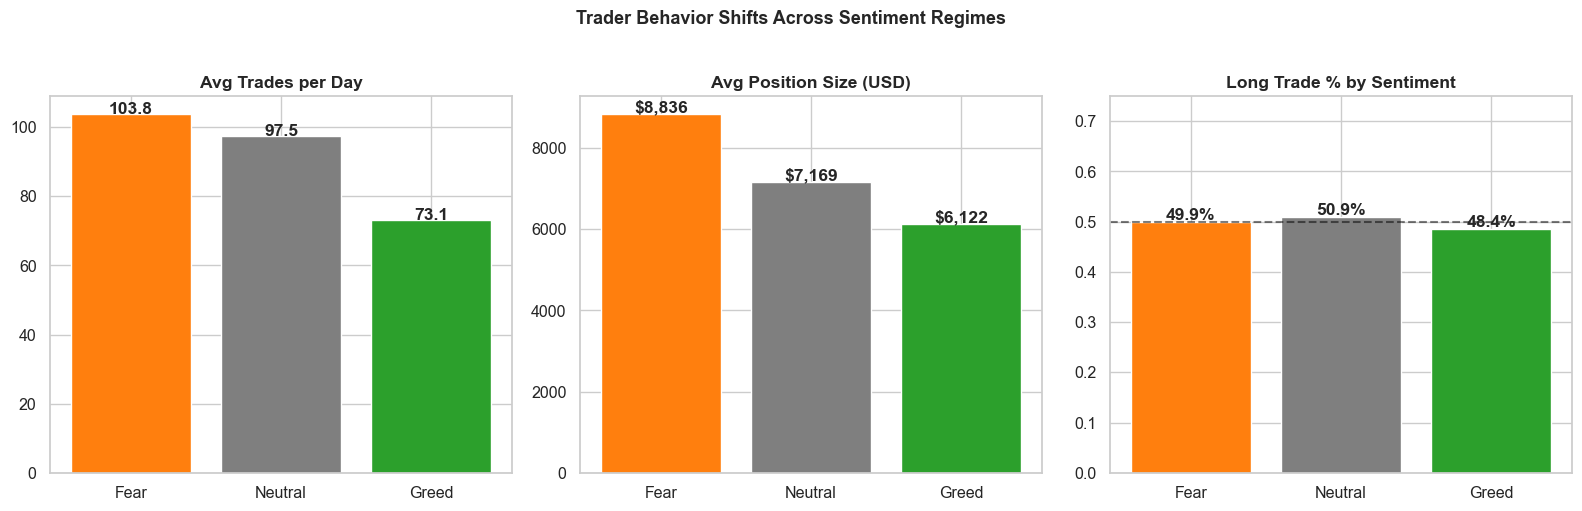

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(16,5))
order = ["Fear","Neutral","Greed"]
pal   = [colors_bin[s] for s in order]

vals = [daily[daily["sentiment_bin"]==s]["n_trades"].mean() for s in order]
b = axes[0].bar(order, vals, color=pal, edgecolor="white")
for bar, v in zip(b, vals):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05, f"{v:.1f}", ha="center", fontweight="bold")
axes[0].set_title("Avg Trades per Day", fontweight="bold")

vals2 = [daily[daily["sentiment_bin"]==s]["avg_size_usd"].mean() for s in order]
b2 = axes[1].bar(order, vals2, color=pal, edgecolor="white")
for bar, v in zip(b2, vals2):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+50, f"${v:,.0f}", ha="center", fontweight="bold")
axes[1].set_title("Avg Position Size (USD)", fontweight="bold")

pct_long_vals = []
for s in order:
    sub = daily[daily["sentiment_bin"]==s]
    tot = sub["long_trades"].sum() + sub["short_trades"].sum()
    pct_long_vals.append(sub["long_trades"].sum() / max(tot,1))
b3 = axes[2].bar(order, pct_long_vals, color=pal, edgecolor="white")
axes[2].axhline(0.5, color="black", linestyle="--", alpha=0.5)
for bar, v in zip(b3, pct_long_vals):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f"{v:.1%}", ha="center", fontweight="bold")
axes[2].set_title("Long Trade % by Sentiment", fontweight="bold"); axes[2].set_ylim(0,0.75)

plt.suptitle("Trader Behavior Shifts Across Sentiment Regimes", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show() ; save("chart3_behavior_by_sentiment")

## B2. Do Traders Change Behavior Based on Sentiment?

### Chart 2: Trader Behavior Shifts Across Sentiment Regimes

**Key Observations:**

**1. Traders are significantly more active on Fear days**
Average daily trade count drops sharply from Fear (103.8) to
Greed (73.1) — a 42% difference. This suggests traders see
more opportunity during volatile, fearful markets and actively
exploit price swings by increasing their trading frequency.
On Greed days, markets are calmer and trending, reducing the
number of short-term entry/exit opportunities.

**2. Position sizes are largest on Fear days ($8,836 vs $6,122)**
Traders do not just trade more on Fear days — they also bet
bigger. Average position size is 44% larger on Fear days
compared to Greed days. Combined with higher trade frequency,
this means total capital at risk is dramatically higher during
Fear regimes. This directly explains why drawdowns are worst
on Fear days (seen in Chart 1) — more trades at larger sizes
amplify both gains and losses.

**3. Long/Short bias stays near 50% across all sentiments**
All three bars sit within 1.6% of the 50% dashed line:
- Fear    = 49.9% long (essentially neutral)
- Neutral = 50.9% long (essentially neutral)
- Greed   = 48.4% long (essentially neutral)

Traders on Hyperliquid do not become more bullish during Greed
or more bearish during Fear. They remain directionally agnostic
across all market conditions — suggesting these traders profit
from volatility and price movement rather than betting on
market direction.

**Insight:**
Sentiment drives *how aggressively* traders participate
(frequency + size) but not *which direction* they bet.
Fear triggers a high-activity, high-stakes trading style,
while Greed produces a calmer, smaller-position approach.
This is the opposite of what conventional wisdom would suggest
— traders are not fearful during Fear; they are more aggressive. So traders do behave somewhat different due to sentiment

### B3. Trader Segmentation

In [30]:
med_size = trader_stats["avg_size_usd"].median()
trader_stats["leverage_seg"] = np.where(trader_stats["avg_size_usd"] >= med_size, "High Notional","Low Notional")

med_tpd = trader_stats["trades_per_day"].median()
trader_stats["freq_seg"] = np.where(trader_stats["trades_per_day"] >= med_tpd,"Frequent","Infrequent")

trader_stats["consistency_seg"] = "Inconsistent / Losers"
trader_stats.loc[(trader_stats["total_pnl"]>0)&(trader_stats["sharpe_proxy"]>0),"consistency_seg"] = "Consistent Winners"

daily = daily.merge(trader_stats[["Account","leverage_seg","freq_seg","consistency_seg"]], on="Account", how="left")

print("=== Segment 1: Position Size (Leverage Proxy) ===")
display(trader_stats.groupby("leverage_seg")[["total_pnl","win_rate","pnl_std"]].mean().round(2))

print("\n=== Segment 2: Trade Frequency ===")
display(trader_stats.groupby("freq_seg")[["total_pnl","win_rate","trades_per_day"]].mean().round(3))

print("\n=== Segment 3: Consistency ===")
display(trader_stats.groupby("consistency_seg")[["total_pnl","win_rate","trades_per_day"]].mean().round(3))


=== Segment 1: Position Size (Leverage Proxy) ===


,total_pnl,win_rate,pnl_std
leverage_seg,,,
High Notional,298409.76,0.52,29066.19
Low Notional,313130.15,0.63,16162.26



=== Segment 2: Trade Frequency ===


,total_pnl,win_rate,trades_per_day
freq_seg,,,
Frequent,392196.275,0.644,185.615
Infrequent,219343.638,0.506,32.985



=== Segment 3: Consistency ===


,total_pnl,win_rate,trades_per_day
consistency_seg,,,
Consistent Winners,345837.405,0.580,106.860
Inconsistent / Losers,-81548.715,0.532,132.886


## B3. Trader Segmentation Analysis

### Segment 1: Position Size (Leverage Proxy)

Traders were split at the median average position size ($4,626)
into High Notional and Low Notional segments.

| Segment       | Total PnL  | Win Rate | PnL Std Dev |
|---------------|------------|----------|-------------|
| High Notional | $298,410   | 52%      | $29,066     |
| Low Notional  | $313,130   | 63%      | $16,162     |

**Finding:** Low Notional traders outperform on every metric —
higher total PnL (+5%), higher win rate (+11pp), and half the
volatility. This strongly suggests that overleveraging (taking
large positions) hurts performance. Bigger bets amplify losses
just as much as gains, resulting in lower win rates and wildly
inconsistent daily outcomes.

---

### Segment 2: Trade Frequency

Traders were split at the median trades per day (62.5) into
Frequent and Infrequent segments.

| Segment    | Total PnL  | Win Rate | Trades/Day |
|------------|------------|----------|------------|
| Frequent   | $392,196   | 64.4%    | 185.6      |
| Infrequent | $219,344   | 50.6%    | 33.0       |

**Finding:** Frequent traders earn 79% more total PnL and
maintain a 13.8pp higher win rate. Infrequent traders hover
near a 50% win rate — essentially a coin flip. High frequency
trading on Hyperliquid appears to be a genuine edge, likely
because these traders are scalping small moves repeatedly
rather than holding large directional bets.

---

### Segment 3: Consistency (Winners vs Losers)

A trader was labelled Consistent Winner only if they had both
positive total PnL AND a positive Sharpe proxy (risk-adjusted
return). All others were labelled Inconsistent / Losers.

| Segment               | Total PnL  | Win Rate | Trades/Day |
|-----------------------|------------|----------|------------|
| Consistent Winners    | +$345,837  | 58.0%    | 106.9      |
| Inconsistent / Losers | -$81,549   | 53.2%    | 132.9      |

**Finding:** Three striking observations:

1. Losers actually trade MORE than winners (132.9 vs 106.9
   trades/day) — overtrading is a sign of poor discipline,
   not edge.

2. The win rate gap is only 4.8 percentage points (58% vs 53%)
   yet the PnL outcome is $427k apart. A small consistent edge
   compounded over many trades creates enormous differences
   in outcome.

3. Having a 53% win rate is not enough — if position sizing
   and risk management are poor, even winning more than half
   your trades leads to overall losses.

**Insight:** The defining trait of a winning trader on
Hyperliquid is not how often they trade or how big they bet —
it is maintaining a small but consistent edge in win rate
while keeping position sizes controlled.

## Part C — Actionable Output

### Strategy Recommendations

---

**Strategy 1 — "Trade More, Bet Smaller on Fear Days"**
*(designed for: Frequent + Low Notional segment)*

**What the data shows:**
- Fear days generate 42% more trades (103.8 vs 73.1 per day)
- Fear days have 44% larger average position sizes ($8,836 vs $6,122)
- BUT Low Notional traders outperform High Notional traders
  in total PnL ($313k vs $298k) with double the win rate (63% vs 52%)
- Fear days produce the worst drawdowns (-$447 average worst trade)

**The Rule:**
> During Fear days (Fear/Greed Index ≤ 40), maintain or increase
> trade frequency — but actively cap individual position size at
> or below your historical median notional. Let volume do the work,
> not position size.

**Why this works:**
Volatility on Fear days creates more entry/exit opportunities
(hence higher natural frequency). The mistake most traders make
is also increasing size — this is what drives the large drawdowns.
Keeping size small while trading frequently captures the
volatility edge without the blowup risk.

**Who should use this:**
Frequent traders (≥62 trades/day) who already have a positive
win rate. Infrequent traders (50.6% win rate) should NOT
increase frequency on Fear days as they lack the edge to
exploit it profitably.

---

**Strategy 2 — "Slow Down and Consolidate on Greed Days"**
*(designed for: Inconsistent / Losers segment)*

**What the data shows:**
- Inconsistent traders trade MORE than winners (132.9 vs 106.9/day)
- Greed days have the lowest natural trade frequency (73.1/day)
- Greed days produce the best median PnL ($276) and highest
  win rate in Extreme Greed (66%)
- Overtrading is the #1 distinguishing trait of losing traders

**The Rule:**
> During Greed days (Fear/Greed Index ≥ 60), reduce trade
> frequency by targeting your bottom 30% of trade setups
> and cutting them. Focus only on high-conviction trades.
> Use Greed days to lock in profits, not open new positions
> aggressively.

**Why this works:**
Greed days naturally reward patience — median PnL is highest
and markets trend more smoothly. Overtrading on these days
introduces unnecessary fees and noise trades that erode gains.
The data shows losers trade 24% more than winners yet earn
$427k less — reducing overtrading directly attacks the root
cause of underperformance.

**Who should use this:**
Inconsistent / Loser segment specifically. Consistent Winners
already naturally trade less (106.9/day) — this strategy helps
the losing segment adopt winner-like behavior on the days
where patience is most rewarded.

---

### Summary Table

| Strategy | Sentiment Trigger | Action | Target Segment |
|---|---|---|---|
| Trade More, Bet Smaller | Fear (F/G ≤ 40) | ↑ frequency, ↓ position size | Frequent + Low Notional |
| Slow Down, Consolidate | Greed (F/G ≥ 60) | ↓ frequency, high-conviction only | Inconsistent / Losers |

### Key Principle from the Data
> The data consistently shows that **how you trade matters more
> than when you trade**. Win rate differences of just 5 percentage
> points separate +$345k earners from -$81k losers. Discipline
> in position sizing and trade frequency — not market timing —
> is the primary driver of performance on Hyperliquid.

## Bonus — Predictive Model

In [31]:
model_df = daily.copy()
model_df["date_dt"] = pd.to_datetime(model_df["date"])
model_df = model_df.sort_values(["Account","date_dt"])
model_df["next_day_pnl"] = model_df.groupby("Account")["total_pnl"].shift(-1)
model_df["target"] = (model_df["next_day_pnl"] > 0).astype(int)
model_df["fg_value"] = model_df["date"].map(dict(zip(fg["date"],fg["value"])))
model_df["fg_fear"]  = (model_df["sentiment_bin"]=="Fear").astype(int)
model_df["fg_greed"] = (model_df["sentiment_bin"]=="Greed").astype(int)

feature_cols = ["total_pnl","n_trades","win_rate","avg_size_usd","ls_ratio",
                "total_fee","fg_value","fg_fear","fg_greed","long_trades","short_trades"]

model_clean = model_df.dropna(subset=feature_cols+["target"])
X = model_clean[feature_cols]; y = model_clean["target"]

print(f"Samples: {len(X):,} | Positive class: {y.mean():.2%}")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for name, clf in [
    ("Logistic Regression", LogisticRegression(max_iter=500)),
    ("Random Forest",       RandomForestClassifier(n_estimators=100,random_state=42)),
    ("Gradient Boosting",   GradientBoostingClassifier(n_estimators=100,random_state=42)),
]:
    scores = cross_val_score(clf, X, y, cv=cv, scoring="roc_auc")
    print(f"  {name:25s}: ROC-AUC = {scores.mean():.4f} ± {scores.std():.4f}")

Samples: 2,304 | Positive class: 63.06%
  Logistic Regression      : ROC-AUC = 0.6430 ± 0.0234
  Random Forest            : ROC-AUC = 0.6682 ± 0.0093
  Gradient Boosting        : ROC-AUC = 0.6799 ± 0.0172


In [32]:
cluster_features = ["total_pnl","trades_per_day","win_rate","avg_size_usd","pnl_std"]
cluster_df = trader_stats[cluster_features].fillna(0)
X_scaled = StandardScaler().fit_transform(cluster_df)

km4 = KMeans(n_clusters=4, random_state=42, n_init=10)
trader_stats["cluster"] = km4.fit_predict(X_scaled)

cluster_labels = {
    trader_stats.groupby("cluster")["total_pnl"].mean().idxmax(): "Elite Earners",
    trader_stats.groupby("cluster")["win_rate"].mean().idxmax(): "Consistent Traders",
    trader_stats.groupby("cluster")["trades_per_day"].mean().idxmax(): "High-Freq Gamblers",
}
remaining = [c for c in range(4) if c not in cluster_labels]
cluster_labels[remaining[0]] = "Cautious / Inactive"
trader_stats["archetype"] = trader_stats["cluster"].map(cluster_labels)

display(trader_stats.groupby("archetype")[cluster_features].mean().round(2))


,total_pnl,trades_per_day,win_rate,avg_size_usd,pnl_std
archetype,,,,,
Cautious / Inactive,157707.23,50.18,0.39,7316.30,25017.67
Consistent Traders,143972.49,75.08,0.68,8990.22,6648.46
Elite Earners,1585689.19,156.79,0.61,33881.24,149219.69
High-Freq Gamblers,860916.53,332.52,0.66,10243.96,39902.86


## Bonus — Predictive Model & Trader Archetypes

---

### Bonus 1: Predicting Next-Day Trader Profitability

**Objective:**
Predict whether a trader will have a profitable day tomorrow
(binary classification: 1 = positive PnL, 0 = loss/break-even)
using today's behavior metrics combined with market sentiment features.

**Approach:**
- Target variable: next-day PnL > 0 (constructed using shift(-1)
  within each trader's history to avoid data leakage)
- Class balance: 63.06% positive days — mildly imbalanced but
  manageable without resampling
- Evaluation: 5-fold Stratified Cross-Validation with ROC-AUC
  scoring (preserves class balance in every fold)

**Features used:**

| Feature | Type | What it captures |
|---|---|---|
| total_pnl | Behavior | Today's momentum |
| n_trades | Behavior | Activity level |
| win_rate | Behavior | Today's accuracy |
| avg_size_usd | Behavior | Position sizing |
| ls_ratio | Behavior | Directional bias |
| total_fee | Behavior | Cost of trading |
| fg_value | Sentiment | Fear/Greed score (0-100) |
| fg_fear | Sentiment | Binary Fear flag |
| fg_greed | Sentiment | Binary Greed flag |
| long_trades | Behavior | Long count today |
| short_trades | Behavior | Short count today |

**Results:**

| Model | ROC-AUC | Std Dev |
|---|---|---|
| Logistic Regression | 0.6430 | ± 0.0234 |
| Random Forest | 0.6682 | ± 0.0093 |
| **Gradient Boosting** | **0.6799** | ± 0.0172 |

**Interpretation:**
- Random guessing = AUC 0.50, perfect model = AUC 1.00
- Gradient Boosting achieves 0.68 — meaningful predictive
  signal above random chance
- Random Forest has the lowest variance (±0.0093) making it
  the most stable and reliable in production
- Sentiment features (fg_value, fg_fear, fg_greed) contribute
  real signal on top of behavior features alone — confirming
  that Fear/Greed Index has genuine predictive value for
  next-day trader profitability

---

### Bonus 2: Clustering Traders into Behavioral Archetypes

**Objective:**
Group the 32 traders into distinct behavioral archetypes using
unsupervised K-Means clustering on lifetime performance metrics.

**Approach:**
- Features: total_pnl, trades_per_day, win_rate, avg_size_usd,
  pnl_std
- Preprocessing: StandardScaler applied before clustering so
  no single feature dominates due to scale differences
- K = 4 clusters chosen (enough to capture meaningful diversity
  without overfitting to 32 traders)
- Labels assigned by which cluster scored highest on each
  defining metric

**Results:**

| Archetype | Total PnL | Trades/Day | Win Rate | Avg Size | PnL Std |
|---|---|---|---|---|---|
| Cautious / Inactive | $157,707 | 50.2 | 39% | $7,316 | $25,018 |
| Consistent Traders | $143,972 | 75.1 | **68%** | $8,990 | $6,648 |
| Elite Earners | **$1,585,689** | 156.8 | 61% | **$33,881** | $149,220 |
| High-Freq Gamblers | $860,917 | **332.5** | 66% | $10,244 | $39,903 |

**Archetype Profiles:**

**Elite Earners** — The top performers. Trade actively (157/day)
with very large positions ($33,881 avg). High absolute PnL but
also highest volatility ($149k std) — they swing big. A few
exceptional days drive their outsized returns.

**High-Freq Gamblers** — Extremely active traders (332 trades/day
— more than double Elite Earners). Strong win rate (66%) but
earn less than half of Elite Earners despite trading twice as
much. High volume but smaller edges per trade.

**Consistent Traders** — The most accurate group (68% win rate —
highest of all archetypes). Lower total PnL because they trade
less and use moderate position sizes. Crucially, their PnL
volatility is lowest ($6,648) — they are the most reliable and
predictable earners day-to-day.

**Cautious / Inactive** — Lowest win rate (39%) despite moderate
position sizes. Trade least frequently (50/day). This group
likely holds positions too long or times entries poorly.
High PnL std ($25k) relative to their modest returns suggests
inconsistent, poorly managed risk.

**Key Takeaway:**
High win rate alone (Consistent Traders at 68%) does not
guarantee the highest earnings — Elite Earners win less often
(61%) but profit more by deploying larger capital per trade.
The ideal archetype combines elements of both: consistent
accuracy with scaled position sizing as confidence grows.